In [8]:
#importing libraries
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

### part a

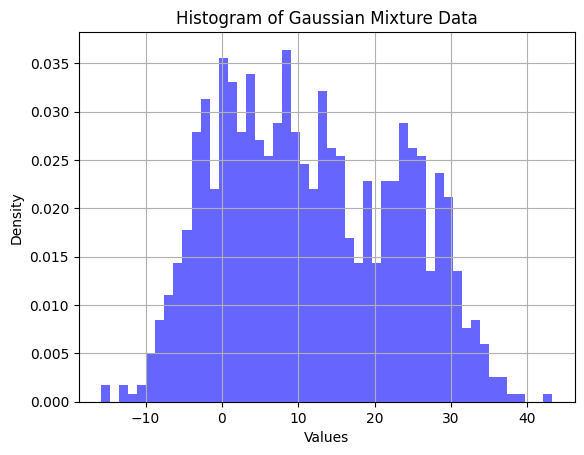

In [9]:
data = np.loadtxt("gaussdata")

# (a) Plot a histogram of the data
plt.hist(data, bins=50, density=True, alpha=0.6, color='b')
plt.title('Histogram of Gaussian Mixture Data')
plt.xlabel('Values')
plt.ylabel('Density')
plt.grid(True)
plt.show()

### part b

In [10]:
# (b) Analyze the data using a Gaussian mixture model
# Specify the range of components to try
min_components = 1
max_components = 20

# Initialize variables to store best results
best_bic = np.inf
best_k = None
best_means = None

# Iterate over different numbers of components
for k in range(min_components, max_components + 1):
    gmm = GaussianMixture(n_components=k)
    gmm.fit(data.reshape(-1, 1))  # Reshape the data for fitting
    
    # Get the BIC score for the current model
    bic = gmm.bic(data.reshape(-1, 1))
    
    # Update best results if BIC is lower
    if bic < best_bic:
        best_bic = bic
        best_k = k
        best_means = gmm.means_

print("Estimated number of components (k):", best_k)
print("Estimated means of the components (μi):", best_means.flatten())

Estimated number of components (k): 3
Estimated means of the components (μi): [11.32754069 -0.11981184 25.38371382]


### Part c

In [11]:
# Define the number of bootstrap samples
num_bootstrap_samples = 100

# Initialize lists to store parameter estimates
k_estimates = []
means_estimates = []

# Non-parametric bootstrap resampling
for _ in range(num_bootstrap_samples):
    # Generate a bootstrap sample by resampling from the original data with replacement
    bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
    
    # Analyze the bootstrap sample using a Gaussian mixture model
    gmm = GaussianMixture(n_components=3)  # Assuming 3 components
    gmm.fit(bootstrap_sample.reshape(-1, 1))
    
    # Get the estimates of the number of components and means
    k_estimates.append(gmm.n_components)
    means_estimates.append(gmm.means_.flatten())

# Aggregate estimates
k_estimate_mean = np.mean(k_estimates)
means_estimate_mean = np.mean(means_estimates, axis=0)

# Compute confidence intervals (optional)
k_estimate_ci = np.percentile(k_estimates, [2.5, 97.5])
means_estimate_ci = np.percentile(means_estimates, [2.5, 97.5], axis=0)

# Print the estimates
print("Estimated number of components (k):", k_estimate_mean)
print("Estimated means of the components (μi):", means_estimate_mean)

# Print confidence intervals (optional)
print("Confidence interval for k:", k_estimate_ci)
print("Confidence interval for means:", means_estimate_ci)


Estimated number of components (k): 3.0
Estimated means of the components (μi): [11.3260089  14.00981148 11.1999172 ]
Confidence interval for k: [3. 3.]
Confidence interval for means: [[-0.60382221 -0.85492081 -0.79307398]
 [26.10038123 25.98952273 25.81525115]]


### part d

In [12]:
# Define the PyMC3 model
with pm.Model() as model:
    # Define prior distributions for parameters
    # For simplicity, we assume uniform priors for the number of components and means
    
    # Number of components (uniform prior)
    k = pm.DiscreteUniform('k', lower=1, upper=10)
    
    # Means of the components (uniform priors)
    means = pm.Uniform('means', lower=data.min(), upper=data.max(), shape=k)
    
    # Define likelihood based on Gaussian mixture model
    components = [pm.Normal.dist(mu=means[i], sd=1) for i in range(k)]
    weights = pm.Dirichlet('weights', a=np.ones(k))  # Prior for component weights
    likelihood = pm.Mixture('likelihood', w=weights, comp_dists=components, observed=data)
    
    # Run MCMC sampling
    trace = pm.sample(1000, tune=1000, chains=2)  # Adjust sampling parameters as needed

# Plot the posterior distribution of the number of components
plt.figure(figsize=(8, 6))
pm.plot_posterior(trace['k'], credible_interval=0.95)
plt.xlabel('Number of Components')
plt.ylabel('Posterior Probability')
plt.title('Posterior Distribution of Number of Components')
plt.grid(True)
plt.show()

# Plot the posterior distribution of means
plt.figure(figsize=(8, 6))
pm.plot_posterior(trace['means'], credible_interval=0.95, kind='hist')
plt.xlabel('Mean')
plt.ylabel('Posterior Probability')
plt.title('Posterior Distribution of Means')
plt.grid(True)
plt.show()


NameError: name 'pm' is not defined